In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
CANDIDATES = [ROOT] + list(ROOT.parents)
PROJECT_ROOT = next((p for p in CANDIDATES if (p / 'src').exists()), ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 04 Modeling
Phan lop trend va du bao chuoi thoi gian walk-forward.

In [2]:
from src.data.loader import load_all_coins
from src.data.cleaner import clean_crypto_dataframe
from src.features.builder import build_features
from src.models.supervised import train_trend_classifier
from src.models.forecasting import run_forecasting_suite
feat_df = build_features(clean_crypto_dataframe(load_all_coins(str(PROJECT_ROOT / 'data' / 'raw'))))
model, metrics, pred, err_shock, report = train_trend_classifier(feat_df)
fm, fd, rr = run_forecasting_suite(feat_df)
metrics

{'accuracy': 1.0,
 'f1': 1.0,
 'roc_auc': 1.0,
 'train_seconds': 14.361021041870117,
 'n_train': 28833,
 'n_test': 7209}

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

palette = {"stormcloud": "#4F6367", "beige": "#EEF5DB", "sunset": "#FE5F55"}
sns.set_theme(style="whitegrid")

In [4]:
metrics_df = pd.DataFrame([metrics])
metrics_df

,accuracy,f1,roc_auc,train_seconds,n_train,n_test
0,1.0,1.0,1.0,14.361021,28833,7209


In [5]:
report.head(10)

,class,precision,recall,f1-score,support
0,0,1.0,1.0,1.0,3411.0
1,1,1.0,1.0,1.0,3798.0
2,accuracy,1.0,1.0,1.0,1.0
3,macro avg,1.0,1.0,1.0,7209.0
4,weighted avg,1.0,1.0,1.0,7209.0


In [6]:
pred.groupby("state_vol")["is_error"].mean().reset_index(name="error_rate")

C:\Users\Admin\AppData\Local\Temp\ipykernel_11540\3541844846.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred.groupby("state_vol")["is_error"].mean().reset_index(name="error_rate")


,state_vol,error_rate
0,low_vol,0.0
1,mid_vol,0.0
2,high_vol,0.0


In [7]:
fm

,model,mae,rmse
0,Naive,681.970112,1215.254253
2,ETS,687.649441,1216.028602
1,ARIMA,700.013017,1230.254675


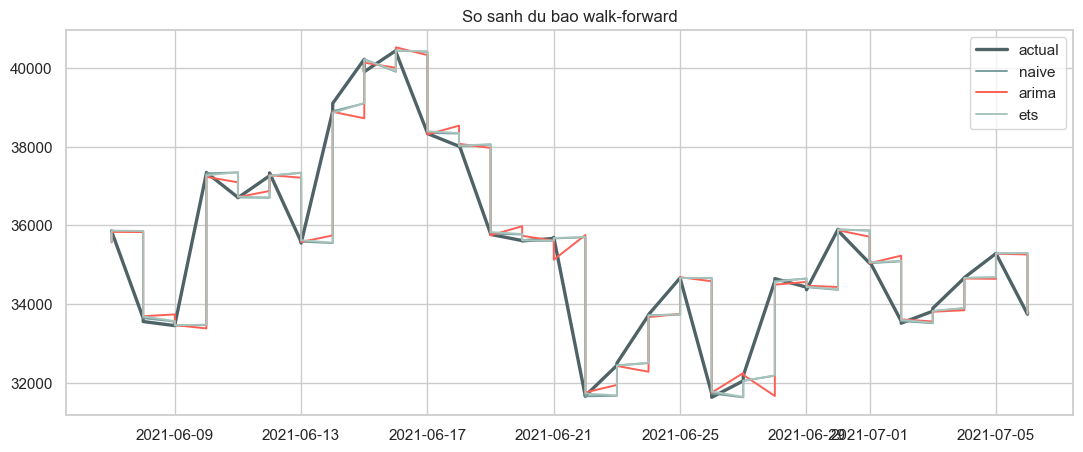

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fd["date"], fd["actual"], color=palette["stormcloud"], linewidth=2.4, label="actual")
ax.plot(fd["date"], fd["naive"], color="#7A9E9F", linewidth=1.4, label="naive")
ax.plot(fd["date"], fd["arima"], color=palette["sunset"], linewidth=1.4, label="arima")
ax.plot(fd["date"], fd["ets"], color="#A7C4BC", linewidth=1.4, label="ets")
ax.legend()
ax.set_title("So sanh du bao walk-forward")
plt.show()

In [9]:
rr

,state_vol,residual_naive,residual_arima,residual_ets
0,low_vol,NaN,NaN,NaN
1,mid_vol,1104.522614,1104.014558,1110.732304
2,high_vol,1222.780008,1238.779651,1223.202973


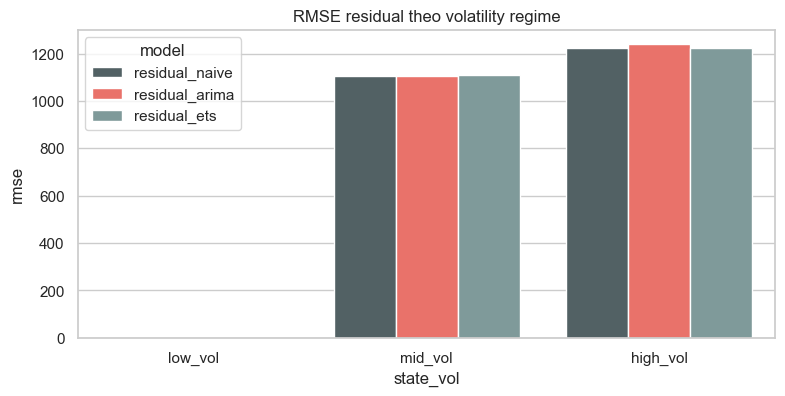

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
rr_long = rr.melt(id_vars=["state_vol"], var_name="model", value_name="rmse")
sns.barplot(data=rr_long, x="state_vol", y="rmse", hue="model", palette=[palette["stormcloud"], palette["sunset"], "#7A9E9F"], ax=ax)
ax.set_title("RMSE residual theo volatility regime")
plt.show()

In [11]:
metrics_df.to_csv("../outputs/tables/notebook04_cls_metrics.csv", index=False)
fm.to_csv("../outputs/tables/notebook04_forecast_metrics.csv", index=False)
rr.to_csv("../outputs/tables/notebook04_residual_regime.csv", index=False)